In [1]:
# 1. IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [7]:
# 2. LOAD DATA
df = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
df

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [8]:
# 3. CLEAN DATA
df.columns = df.columns.str.replace('ï»¿', '')

# Drop useless columns
drop_cols = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
for col in drop_cols:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

In [9]:
# 4. TARGET ENCODING
label = LabelEncoder()
df["Attrition"] = label.fit_transform(df["Attrition"])  # 0 / 1

# Separate target FIRST
y = df["Attrition"]

# Remove target from features
df = df.drop("Attrition", axis=1)

In [10]:
# 5. ONE-HOT ENCODING
df = pd.get_dummies(df, drop_first=True)

X = df

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1470, 44)
y shape: (1470,)


In [11]:
# 6. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [12]:
# 7. LOGISTIC REGRESSION
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("\n====== LOGISTIC REGRESSION ======")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))


====== LOGISTIC REGRESSION ======
Confusion Matrix:
 [[237  10]
 [ 31  16]]
Accuracy: 0.8605442176870748
Precision: 0.6153846153846154
Recall: 0.3404255319148936
F1 Score: 0.4383561643835616

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



In [13]:
# 8. RANDOM FOREST
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\n====== RANDOM FOREST ======")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))


====== RANDOM FOREST ======
Confusion Matrix:
 [[240   7]
 [ 42   5]]
Accuracy: 0.8333333333333334
Precision: 0.4166666666666667
Recall: 0.10638297872340426
F1 Score: 0.1694915254237288

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.42      0.11      0.17        47

    accuracy                           0.83       294
   macro avg       0.63      0.54      0.54       294
weighted avg       0.78      0.83      0.79       294



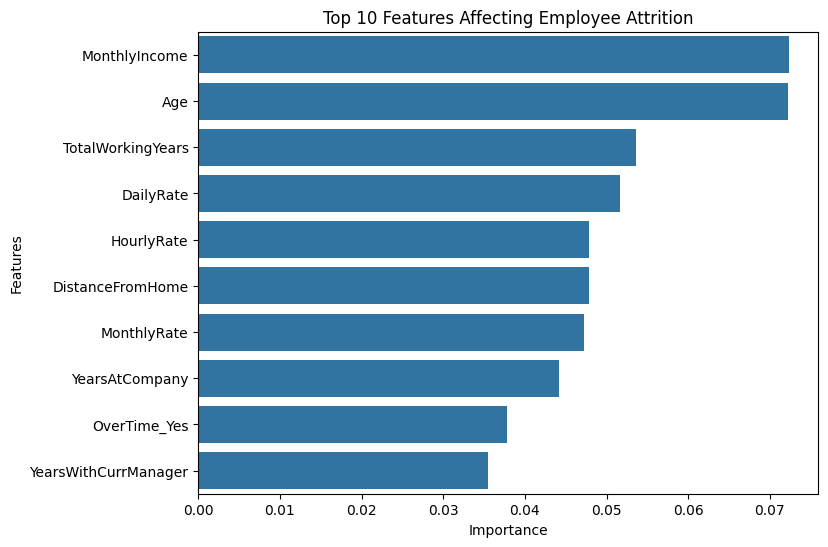

In [14]:
# 9. FEATURE IMPORTANCE
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_features = importances.nlargest(10)

plt.figure(figsize=(8,6))
sns.barplot(x=top_features.values, y=top_features.index)
plt.title("Top 10 Features Affecting Employee Attrition")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()


In [15]:
# 10. SAVE MODEL
with open("attrition_model.pkl", "wb") as f:
    pickle.dump(rf, f)

with open("features.pkl", "wb") as f:
    pickle.dump(X.columns.tolist(), f)

In [16]:
# 11. FINAL SUMMARY
print("\n====== FINAL COMPARISON ======")
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\n Logistic Regression is the best model based on performance.")


====== FINAL COMPARISON ======
Logistic Regression Accuracy: 0.8605442176870748
Random Forest Accuracy: 0.8333333333333334

 Logistic Regression is the best model based on performance.


In [17]:
# SECTION 1: Model Evaluation
from sklearn.metrics import classification_report, confusion_matrix

y_pred_rf = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[240   7]
 [ 42   5]]
              precision    recall  f1-score   support

           0       0.85      0.97      0.91       247
           1       0.42      0.11      0.17        47

    accuracy                           0.83       294
   macro avg       0.63      0.54      0.54       294
weighted avg       0.78      0.83      0.79       294



In [18]:
# SECTION 2: Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

In [19]:
#SECTION 3: Compare BEFORE vs AFTER
from sklearn.metrics import accuracy_score

y_pred_old = rf.predict(X_test)
y_pred_new = best_rf.predict(X_test)

print("Old Accuracy:", accuracy_score(y_test, y_pred_old))
print("Tuned Accuracy:", accuracy_score(y_test, y_pred_new))

Old Accuracy: 0.8333333333333334
Tuned Accuracy: 0.8435374149659864


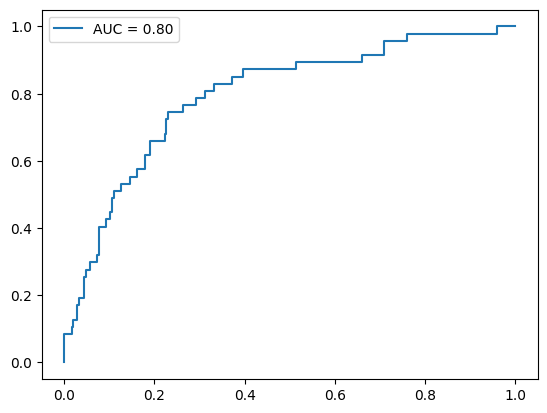

In [20]:
#SECTION 4: ROC Curve
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = best_rf.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label="AUC = %.2f" % roc_auc)
plt.legend()
plt.show()